## 1.importance des librairies 

In [187]:
# Importance des librairies

import numpy as np
import pandas as pd

## 2.Chargement des donnees

In [188]:
#  chargement des donnees

data = pd.read_csv('data/studentscores.csv')
data.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


## 3.analyse des donnees 

In [189]:
# analyse des donnees 

# 1. isnull

data.isnull()

,Hours,Scores
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
5,False,False
6,False,False
7,False,False
8,False,False
9,False,False


In [190]:
# isnull().sum()

data.isnull().sum()

Hours     0
Scores    0
dtype: int64

In [191]:
# data.infos()

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 528.0 bytes


In [192]:
data['Hours'].max()

np.float64(9.2)

In [193]:
data['Hours'].min()

np.float64(1.1)

In [194]:
print('Score Max: ', data['Scores'].max())

Score Max:  95


In [195]:
print('Score Min: ', data['Scores'].min())

Score Min:  17


## 4. division des donnees 

In [196]:
# donnees
data.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


## variables independantes et dependantes 

In [197]:
### variables dependantes

x= data.iloc[:, :-1]
y= data.iloc[:, -1]

x

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5
5,1.5
6,9.2
7,5.5
8,8.3
9,2.7


In [198]:
y

0     21
1     47
2     27
3     75
4     30
5     20
6     88
7     60
8     81
9     25
10    85
11    62
12    41
13    42
14    17
15    95
16    30
17    24
18    67
19    69
20    30
21    54
22    35
23    76
24    86
Name: Scores, dtype: int64

In [199]:
x= data.iloc[:, :-1].values
y= data.iloc[:, -1].values

y

array([21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 30,
       24, 67, 69, 30, 54, 35, 76, 86])

## 4.separation des donnees:train et test

In [200]:
## x_train

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=40)

print('x_train shape: ', x_train.shape)
print('x_test shape: ', x_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ', y_test.shape)

x_train shape:  (18, 1)
x_test shape:  (7, 1)
y_train shape:  (18,)
y_test shape:  (7,)


## 5.construction du modele

In [201]:
## importation

from sklearn.linear_model import LinearRegression

In [202]:
## creation du modele

modele_lineaire = LinearRegression()

In [203]:
## entraiment  du modele 

modele_lineaire.fit(x_train, y_train)

LinearRegression()

In [204]:
## prediction a l'aide des x_test

y_scores_predits = modele_lineaire.predict(x_test)

y_scores_predits

array([90.34862057, 79.20125828, 11.303688  , 75.147672  , 33.59841257,
       86.29503428, 48.79936114])

In [205]:
##  comparaison avec y_test

y_test

array([95, 86, 17, 69, 42, 75, 54])

In [226]:
resultats  = pd.DataFrame(y_test,y_scores_predits)

In [207]:
resultats

,0
90.348621,95
79.201258,86
11.303688,17
75.147672,69
33.598413,42
86.295034,75
48.799361,54


### 6.evaluation du modele

In [208]:
## importations 

from sklearn.metrics import mean_squared_error, r2_score

In [209]:
## mean_squared_error 

print('MSE de la regression Lineaire:',mean_squared_error(y_test, y_scores_predits))

MSE de la regression Lineaire: 51.90159659147337


In [210]:
print('r2_score de la regression Lineaire:',r2_score(y_test, y_scores_predits))

r2_score de la regression Lineaire: 0.9168569951293908


In [211]:
import matplotlib.pyplot as plt

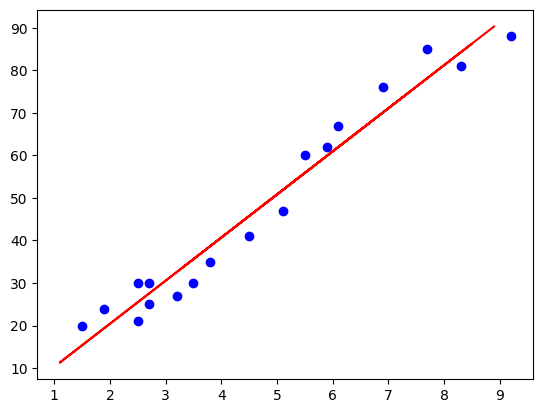

In [223]:
#### scatter: eparpiller

plt.scatter(x_train, y_train, color='blue' , label='Train data')
plt.plot(x_test, y_scores_predits, color='red' , label='Ligne de la Regression Lineaire')
plt.show()


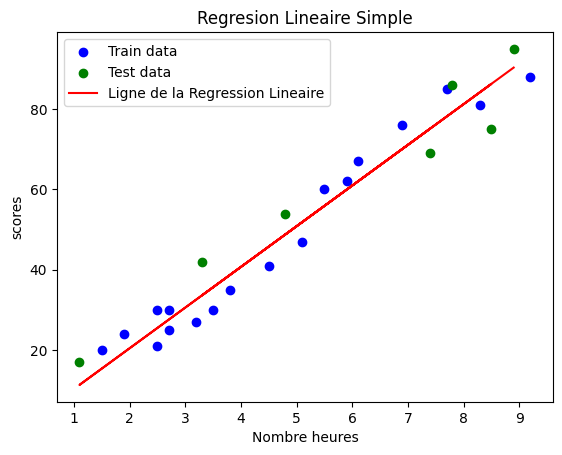

In [221]:
## scatter: eparpiller

plt.scatter(x_train, y_train, color='blue' , label='Train data')
plt.scatter(x_test, y_test, color='green' , label='Test data')
plt.plot(x_test, y_scores_predits, color='red' , label='Ligne de la Regression Lineaire')
plt.xlabel('Nombre heures')
plt.ylabel('scores')
plt.title('Regresion Lineaire Simple')
plt.legend()
plt.show()


## 7. prediction simple

In [214]:
data.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [218]:
resultats = pd.DataFrame({'y-score-reel':y_test, 'y-scores-predits':y_scores_predits})
resultats

,y-score-reel,y-scores-predits
0,95,90.348621
1,86,79.201258
2,17,11.303688
3,69,75.147672
4,42,33.598413
5,75,86.295034
6,54,48.799361


In [219]:
y_scores_predits

array([90.34862057, 79.20125828, 11.303688  , 75.147672  , 33.59841257,
       86.29503428, 48.79936114])

In [220]:
y

array([21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 30,
       24, 67, 69, 30, 54, 35, 76, 86])

In [222]:
print(modele_lineaire.predict([[10]]))

[101.49598285]


In [224]:
resultats = pd.DataFrame({'y-score-reel':y_test, 'y-scores-predits':y_scores_predits,'Difference':y_test-y_scores_predits})
resultats

,y-score-reel,y-scores-predits,Difference
0,95,90.348621,4.651379
1,86,79.201258,6.798742
2,17,11.303688,5.696312
3,69,75.147672,-6.147672
4,42,33.598413,8.401587
5,75,86.295034,-11.295034
6,54,48.799361,5.200639
